# **머신러닝 모델링(퀴즈)**

+ 이번시간에는 머신러닝 프로세스를 따라서 실습해 보겠습니다.
+ 즉, 데이터 파일 읽기, EDA 데이터 분석, 데이터 전처리, Train, Test 데이터셋 분할, 정규화, 모델 생성 및 학습 순으로 진행하겠습니다.
+ 아래와 같은 여러가지 머신러닝 모델에 대해서 살펴 보고 어떤 모델이 성능이 더 좋은지도 같이 보도록 하겠습니다.
     + 단일 분류예측 모델 : LogisticRegression, KNN, DecisionTree
     + 앙상블(Ensemble) 모델 : RandomForest, XGBoost
+ 솔직히, 머신러닝이 딥러닝보다 코딩하기 쉽습니다. 4줄 템플릿에 맞쳐 코딩하면 되기 때문입니다.
+ 한가지 당부 드리고 싶은 말은 "백문이불여일타" 입니다. 
+ 이론보다 실습이 더 많은 시간과 노력이 투자 되어야 합니다.

### **학습목차**
- 머신러닝 모델 프로세스
     - 데이터 가져오기
     - 데이터 전처리
     - Train, Test 데이터셋 분할
     - 데이터 정규화
     - 단일 분류예측 모델 : LogisticRegression, KNN, DecisionTree
     - 앙상블(Ensemble) 모델 : RandomForest, XGBoost, LGBM, Stacking, Weighted Blending


# 
## **1. 실습을 위한 셋팅 설정**

In [146]:
# 코드실행시 경고 메시지 무시

import warnings
warnings.filterwarnings(action='ignore') 

#
## **2. 머신러닝 모델 프로세스**
① 라이브러리 임포트(import)  
② 데이터 가져오기(Loading the data)  
③ 탐색적 데이터 분석(Exploratory Data Analysis)  
④ 데이터 전처리(Data PreProcessing) : 데이터타입 변환, Null 데이터 처리, 누락데이터 처리, 
더미특성 생성, 특성 추출 (feature engineering) 등  
⑤ Train, Test  데이터셋 분할  
⑥ 데이터 정규화(Normalizing the Data)  
⑦ 모델 개발(Creating the Model)  
⑧ 모델 성능 평가

####
### **① 라이브러리 임포트**

##### 필요 라이브러리 임포트

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

####
### **② 데이터 로드**

#### cust_data1.csv 파일 컬럼명
+ 고객등급(class), 성별(sex), 나이(age), 사용서비스수(service), 서비스중지여부 (stop), 미납여부(npay)
+ 3개월 평균 요금(avg_bill), A서비스 3개월 평균요금(A_bill), B서비스 3개월 평균요금(B_bill), 해지여부(termination)

In [148]:
# 앞쪽 전처리에서 저장한 cust_data1.csv 파일 읽기
df = pd.read_csv('../cust_data1.csv')

####
### **③ 데이터 분석**

In [3]:
# 10컬럼, 9930 라인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8228 non-null   str    
 1   sex          8228 non-null   str    
 2   age          8228 non-null   float64
 3   service      8228 non-null   int64  
 4   stop         8228 non-null   str    
 5   npay         8228 non-null   str    
 6   avg_bill     8228 non-null   float64
 7   A_bill       8228 non-null   float64
 8   B_bill       8228 non-null   float64
 9   termination  8228 non-null   str    
dtypes: float64(4), int64(1), str(5)
memory usage: 642.9 KB


In [4]:
df.tail()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
8223,C,M,76.0,1,N,N,1860.0000,1716.000000,0.0000,N
8224,C,F,15.0,1,N,Y,1296.0999,194.414985,643.1001,N
8225,G,M,12.0,1,N,N,13799.6666,2069.949990,10605.9266,N
8226,C,F,40.0,0,N,N,3140.0000,942.000000,1884.0000,Y
8227,C,F,59.0,1,N,N,2436.9000,365.535000,1839.9000,N


##### <font color=blue> **[문제] df DataFrame에 대해서 아래 조건에 맞는 boolean indexing을 하세요.** </font>
- 대상 데이터프레임 : df
- 조건에 맞는 리스트 출력
    - 조건 : 성별(sex)이 남자(M)이고 평균요금(avg_bill)이 130000 이상

In [149]:
# Boolean indexing 검색
# 조건 : 성별(sex)이 남자(M)이고 평균요금(avg_bill)이 130000 이상
# 1. 성별(sex) : 남자  >> df[ 'sex' ] == 'M' 
# 2. 평균요금(avg_bill)  13000 이상 >> df[ 'avg_bill' ] >= 130000
condition = (df['sex'] == 'M') & (df['avg_bill'] >= 130000)
df[condition]

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
1198,D,M,30.0,0,N,N,144739.6866,131581.5333,0.0,Y


<Axes: xlabel='termination'>

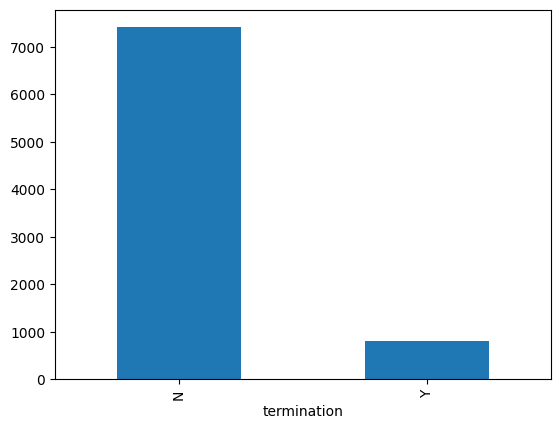

In [150]:
# termination 레이블 불균형 
df['termination'].value_counts().plot(kind='bar')

####
### **④ 데이터 전처리**

In [24]:
# 문자열 데이터 : class , sex, stop, npay, termination
df.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,N,2640.0000,792.00000,1584.0000,Y
1,E,F,24.0,1,N,N,16840.0000,2526.00000,6983.0000,N
2,F,F,32.0,1,N,N,15544.7334,2331.71001,6750.4666,N
3,D,M,18.0,1,N,N,4700.0000,0.00000,4502.0000,N
4,C,F,78.0,1,N,N,1361.7999,1173.99990,0.0000,N


##### <font color=blue> ⭐️ **[문제] replace 함수를 사용해서 'termination' 컬럼을 모델이 이해할수 있도록 Y --> 1 , N--> 0으로 변경하세요** </font>

In [151]:
# 대상 : df 데이터프레임 
# replace 함수 적용 대상 컬럼 : termination
# 방법1 :  replace( 'Y' , 1 ), replace( 'N' , 0 ) 각각 변경 적용
# 방법2 : df[ 'termination' ].replace( ['Y', 'N'] , [1, 0] ) 이렇게 한번에 적용

df['termination'] = df['termination'].map({'Y': 1, 'N': 0}).astype('int')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8228 non-null   str    
 1   sex          8228 non-null   str    
 2   age          8228 non-null   float64
 3   service      8228 non-null   int64  
 4   stop         8228 non-null   str    
 5   npay         8228 non-null   str    
 6   avg_bill     8228 non-null   float64
 7   A_bill       8228 non-null   float64
 8   B_bill       8228 non-null   float64
 9   termination  8228 non-null   int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 642.9 KB


In [14]:
# termination 컬럼에 대해 replace 함수 적용후 확인
df.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,N,2640.0000,792.00000,1584.0000,1
1,E,F,24.0,1,N,N,16840.0000,2526.00000,6983.0000,0
2,F,F,32.0,1,N,N,15544.7334,2331.71001,6750.4666,0
3,D,M,18.0,1,N,N,4700.0000,0.00000,4502.0000,0
4,C,F,78.0,1,N,N,1361.7999,1173.99990,0.0000,0


In [27]:
# 라벨인코더 임포트
from sklearn.preprocessing import LabelEncoder

##### <font color=blue> **[문제] df DataFrame에서 'npay' 컬럼을 모델이 이해할수 있도록 라벨인코딩하세요.** </font>

In [152]:
# 대상 : df 데이터프레임 
# 라벨인코더 대상 컬럼 : npay
# LabelEncoder() 함수를 le 정의 및 fit_transform 적용
le = LabelEncoder()
df['npay'] = le.fit_transform(df['npay'])

In [153]:
# npay 컬럼에 대해 라벨인코더 적용후 확인
df.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,0,2640.0000,792.00000,1584.0000,1
1,E,F,24.0,1,N,0,16840.0000,2526.00000,6983.0000,0
2,F,F,32.0,1,N,0,15544.7334,2331.71001,6750.4666,0
3,D,M,18.0,1,N,0,4700.0000,0.00000,4502.0000,0
4,C,F,78.0,1,N,0,1361.7999,1173.99990,0.0000,0


In [60]:
# 나머지 문자열 컬럼들 
cal_cols = ['class', 'sex', 'stop']

##### <font color=blue> ⭐️ **[문제] 나머지 Object 컬럼에 대해 Pandas get_dummies 함수 활용하여 원핫인코딩하세요.** </font>

In [156]:
# 대상 : df 데이터프레임 
# 원핫인코딩 대상 컬럼 : 'class', 'sex', 'stop'
# Pandas get_dummies 함수 활용
# get_dummies 함수의 옵션으로 가변수 제거하는 drop_first=True 설정
df = pd.get_dummies(data=df, columns=cal_cols, drop_first=True, dtype='int') # ⭐️

In [107]:
# 기존 1개의 class 컬럼이  5개의 class_D, class_E, class_F, class_G, class_H 컬럼으로 원핫인코딩 확인
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          8228 non-null   float64
 1   service      8228 non-null   int64  
 2   npay         8228 non-null   int64  
 3   avg_bill     8228 non-null   float64
 4   A_bill       8228 non-null   float64
 5   B_bill       8228 non-null   float64
 6   termination  8228 non-null   int64  
 7   class_D      8228 non-null   int64  
 8   class_E      8228 non-null   int64  
 9   class_F      8228 non-null   int64  
 10  class_G      8228 non-null   int64  
 11  class_H      8228 non-null   int64  
 12  sex_M        8228 non-null   int64  
 13  stop_Y       8228 non-null   int64  
dtypes: float64(4), int64(10)
memory usage: 900.1 KB


,age,service,npay,avg_bill,A_bill,B_bill,termination,class_D,class_E,class_F,class_G,class_H,sex_M,stop_Y
0,28.0,0,0,2640.0000,792.00000,1584.0000,1,0,0,0,0,0,0,0
1,24.0,1,0,16840.0000,2526.00000,6983.0000,0,0,1,0,0,0,0,0
2,32.0,1,0,15544.7334,2331.71001,6750.4666,0,0,0,1,0,0,0,0
3,18.0,1,0,4700.0000,0.00000,4502.0000,0,1,0,0,0,0,1,0
4,78.0,1,0,1361.7999,1173.99990,0.0000,0,0,0,0,0,0,0,0


####
### **⑤ Train, Test  데이터셋 분할**

#### 입력(X)과 레이블(y) 나누기

##### <font color=blue> **[문제] df DataFrame에서 'termination' 컬럼을 제외한 나머지 정보를 X에 저장하세요.** </font>

In [ ]:
# 대상 : df 데이터프레임 
# DataFrame drop 함수 활용
# 'termination' 컬럼 삭제
# DataFrame에서 values만 X에 저장 ⭐️
X = df.drop(columns='termination').values

##### <font color=blue> **[문제] df DataFrame에서 'termination' 컬럼을 y로 저장하세요.** </font>

In [ ]:
# 대상 : df 데이터프레임
# DataFrame 'termination' 컬럼 사용
# DataFrame에서 values만 y에 저장 ⭐️
y = df['termination'].values

In [110]:
X.shape, y.shape

((8228, 13), (8228,))

#### Train , Test dataset 나누기

In [39]:
from sklearn.model_selection import train_test_split

##### <font color=blue> **[문제] Train dataset, Test dataset 나누세요.** </font>

In [ ]:
# Train dataset, Test dataset 나누기 : train_test_split 함수 사용
# 입력 : X, y 
# Train : Test 비율 = 7: 3  --> test_size=0.3
# y Class 비율에 맞게 나주어 주세요 : stratify=y ⭐️
# 여러번 수행해도 같은 결과 나오게 고정하기 : random_state=42 
# 결과 : X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [92]:
X_train.shape, X_test.shape

((5759, 13), (2469, 13))

In [93]:
y_train.shape, y_test.shape

((5759,), (2469,))

####
### **⑥ 데이터 정규화/스케일링(Normalizing/Scaling)**

In [94]:
# 숫자 분포 이루어진 컬럼 확인
df.tail() # age, bill 컬럼을 비교해보면 bill의 숫자 사이즈가 크므로 bill에 영향도가 높을 수 있음. 정규화 필요

,age,service,npay,avg_bill,A_bill,B_bill,termination,class_D,class_E,class_F,class_G,class_H,sex_M,stop_Y
8223,76.0,1,0,1860.0000,1716.000000,0.0000,0,0,0,0,0,0,1,0
8224,15.0,1,1,1296.0999,194.414985,643.1001,0,0,0,0,0,0,0,0
8225,12.0,1,0,13799.6666,2069.949990,10605.9266,0,0,0,0,1,0,1,0
8226,40.0,0,0,3140.0000,942.000000,1884.0000,1,0,0,0,0,0,0,0
8227,59.0,1,0,2436.9000,365.535000,1839.9000,0,0,0,0,0,0,0,0


In [44]:
from sklearn.preprocessing import MinMaxScaler

##### <font color=blue> **[문제] MinMaxScaler 함수를 'scaler'로 정의 하세요.** </font>

In [46]:
# 사이키런의 MinMaxScaler() 함수 활용
# 정의할 결과를 'scaler'로 매핑
scaler = MinMaxScaler()

In [158]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # ⭐️

In [159]:
# 출력된 값들이 0~1사이의 값들로 변한걸 확인
X_train[:2], y_train[:2]

(array([[0.60824742, 0.45454545, 0.        , 0.08540698, 0.01766813,
         0.1391709 , 0.        , 0.        , 1.        , 0.        ,
         0.        , 1.        , 0.        ],
        [0.48453608, 0.        , 0.        , 0.04043276, 0.01399892,
         0.05595675, 1.        , 0.        , 0.        , 0.        ,
         0.        , 1.        , 0.        ]]),
 array([0, 1]))

####
### **⑦ 모델 개발**

#### 모델별 바차트 그려주고 성능 확인을 위한 함수

In [53]:
# 모델별로 Accuracy 점수 저장
# 모델 Accuracy 점수 순서대로 바차트를 그려 모델별로 성능 확인 가능

from sklearn.metrics import accuracy_score

my_predictions = {}

colors = ['r', 'c', 'm', 'y', 'k', 'khaki', 'teal', 'orchid', 'sandybrown',
          'greenyellow', 'dodgerblue', 'deepskyblue', 'rosybrown', 'firebrick',
          'deeppink', 'crimson', 'salmon', 'darkred', 'olivedrab', 'olive', 
          'forestgreen', 'royalblue', 'indigo', 'navy', 'mediumpurple', 'chocolate',
          'gold', 'darkorange', 'seagreen', 'turquoise', 'steelblue', 'slategray', 
          'peru', 'midnightblue', 'slateblue', 'dimgray', 'cadetblue', 'tomato'
         ]

# 모델명, 예측값, 실제값을 주면 위의 plot_predictions 함수 호출하여 Scatter 그래프 그리며
# 모델별 MSE값을 Bar chart로 그려줌
def accuracy_eval(name_, pred, actual):
    global predictions
    global colors

    plt.figure(figsize=(12, 9))

    acc = accuracy_score(actual, pred)
    my_predictions[name_] = acc * 100

    y_value = sorted(my_predictions.items(), key=lambda x: x[1], reverse=True)
    
    df = pd.DataFrame(y_value, columns=['model', 'accuracy'])
    print(df)
   
    length = len(df)
    
    plt.figure(figsize=(10, length))
    ax = plt.subplot()
    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(df['model'], fontsize=15)
    bars = ax.barh(np.arange(len(df)), df['accuracy'])
    
    for i, v in enumerate(df['accuracy']):
        idx = np.random.choice(len(colors))
        bars[i].set_color(colors[idx])
        ax.text(v + 2, i, str(round(v, 3)), color='k', fontsize=15, fontweight='bold')
        
    plt.title('accuracy', fontsize=18)
    plt.xlim(0, 100)
    
    plt.show()

####  
### **1) 로지스틱 회귀 (LogisticRegression, 분류)**

In [ ]:
from sklearn.linear_model import LogisticRegression # ⭐️
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

##### <font color=blue> ⭐️ **[문제] LogisticRegression 모델 정의하고 학습시키세요.** </font>

In [133]:
# LogisticRegression 함수 사용 및 정의 : lg 저장
# 정의된 LogisticRegression 학습 fit() : 입력값으로 X_train, y_train 준다.
lg = LogisticRegression()
lg.fit(X_train, y_train) # ⭐️

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [114]:
# 분류기 성능 평가(score)
lg.score(X_test, y_test)

0.9194005670311867

- 분류기 성능 평가 지표

In [115]:
lg_pred = lg.predict(X_test)

In [116]:
# 오차행렬 ⭐️
# TN  FP
# FN  TP

confusion_matrix(y_test, lg_pred) # 정답, 예측값 순
# array([[2219,    5],
#        [ 194,   51]])

array([[2219,    5],
       [ 194,   51]])

In [117]:
# 정확도 : 굉장히 높다
accuracy_score(y_test, lg_pred)  

0.9194005670311867

In [118]:
# 정밀도
precision_score(y_test, lg_pred) 

0.9107142857142857

In [119]:
# 재현율(정답 중에서 내가 맞춘 비율) : 굉장히 낮다.
recall_score(y_test, lg_pred)  

0.20816326530612245

In [120]:
# 정밀도 + 재현율
f1_score(y_test, lg_pred) 

0.3388704318936877

In [121]:
print(classification_report(y_test, lg_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      2224
           1       0.91      0.21      0.34       245

    accuracy                           0.92      2469
   macro avg       0.92      0.60      0.65      2469
weighted avg       0.92      0.92      0.90      2469



                model   accuracy
0  LogisticRegression  91.940057


<Figure size 1200x900 with 0 Axes>

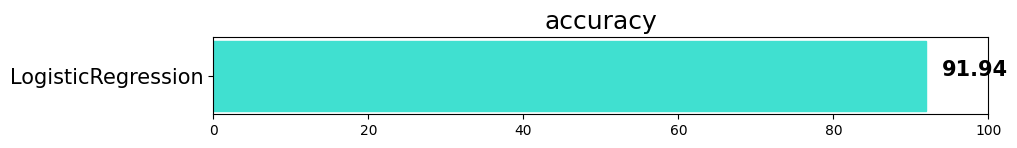

In [122]:
accuracy_eval('LogisticRegression', lg_pred, y_test)

####   
### **2) KNN (K-Nearest Neighbor)**

In [123]:
from sklearn.neighbors import KNeighborsClassifier

##### <font color=blue> **[문제] KNeighborsClassifier 모델 정의하고 학습시키세요.** </font>

In [125]:
# KNeighborsClassifier 함수 사용 및 정의 : knn 저장
# 정의된 KNeighborsClassifier 학습 fit() : 입력값으로 X_train, y_train 준다.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [126]:
knn_pred = knn.predict(X_test)

                model   accuracy
0  K-Nearest Neighbor  95.909275
1  LogisticRegression  91.940057


<Figure size 1200x900 with 0 Axes>

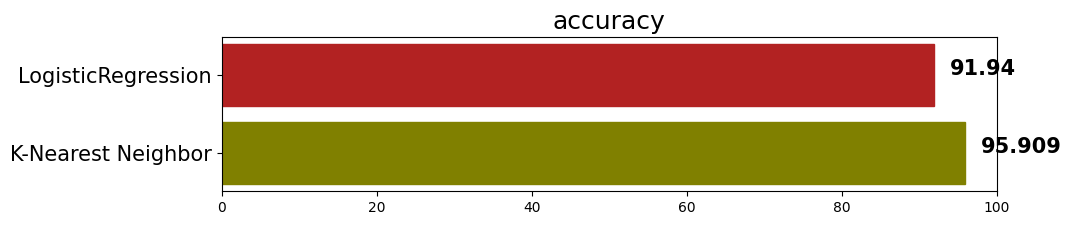

In [128]:
accuracy_eval('K-Nearest Neighbor', knn_pred, y_test)

####  
### **3) 결정트리(DecisionTree)**

In [129]:
from sklearn.tree import DecisionTreeClassifier

In [130]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

##### <font color=blue> **[문제] 학습된 DecisionTreeClassifier 모델로 예측해 보기** </font>

In [131]:
# DecisionTreeClassifier 학습 모델 : dt
# DecisionTreeClassifier 모델의 predict() 활용 : 입력값으로 X_test
# 결과 : dt_pred 저장
dt_pred = dt.predict(X_test)

                model   accuracy
0        DecisionTree  97.934386
1  K-Nearest Neighbor  95.909275
2  LogisticRegression  91.940057


<Figure size 1200x900 with 0 Axes>

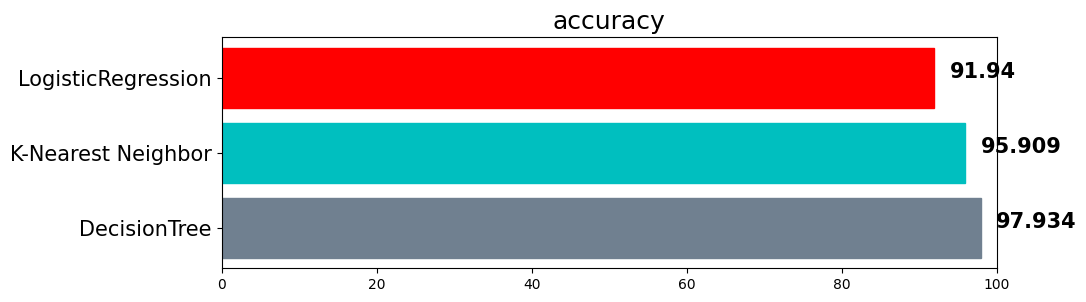

In [132]:
accuracy_eval('DecisionTree', dt_pred, y_test)

### 
### **앙상블 기법의 종류** ⭐️
- ⭐️ 배깅 (Bagging): 여러개의 DecisionTree 활용하고 샘플 중복 생성을 통해 결과 도출. RandomForest
- ⭐️ 부스팅 (Boosting): 약한 학습기를 순차적으로 학습을 하되, 이전 학습에 대하여 잘못 예측된 데이터에 가중치를 부여해 오차를 보완해 나가는 방식. XGBoost, LGBM
- ⭐️ 스태킹 (Stacking): 여러 모델을 기반으로 예측된 결과를 통해 Final 학습기(meta 모델)이 다시 한번 예측

![앙상블](https://teddylee777.github.io/images/2019-12-18/image-20191217144823555.png)

####  
### **4) 랜덤포레스트(RandomForest)**
+ Bagging 대표적인 모델로써, 훈련셋트를 무작위로 각기 다른 서브셋으로 데이터셋을 만들고
+ 여러개의 DecisonTree로 학습하고 다수결로 결정하는 모델

**주요 Hyperparameter** ⭐️
- random_state: 랜덤 시드 고정 값. 고정해두고 튜닝할 것!
- n_jobs: CPU 사용 갯수
- max_depth: 깊어질 수 있는 최대 깊이. 과대적합 방지용
- n_estimators: 앙상블하는 트리의 갯수
- max_features: 최대로 사용할 feature의 갯수. 과대적합 방지용
- min_samples_split: 트리가 분할할 때 최소 샘플의 갯수. default=2. 과대적합 방지용

In [135]:
from sklearn.ensemble import RandomForestClassifier

##### <font color=blue> **[문제] RandomForestClassifier 모델 정의하고 학습시키세요.** </font>

In [136]:
# RandomForestClassifier 함수 사용 및 정의 : rfc 저장
# RandomForestClassifier 함수 정의시 n_estimators=3, random_state=42 하이퍼라파미터 설정하기
# 정의된 RandomForestClassifier 학습 fit() : 입력값으로 X_train, y_train 준다.
rfc = RandomForestClassifier(n_estimators=3, random_state=42)
rfc.fit(X_train, y_train)





,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [137]:
rfc_pred = rfc.predict(X_test)

                   model   accuracy
0           DecisionTree  97.934386
1  RandomForest Ensemble  97.812880
2     K-Nearest Neighbor  95.909275
3     LogisticRegression  91.940057


<Figure size 1200x900 with 0 Axes>

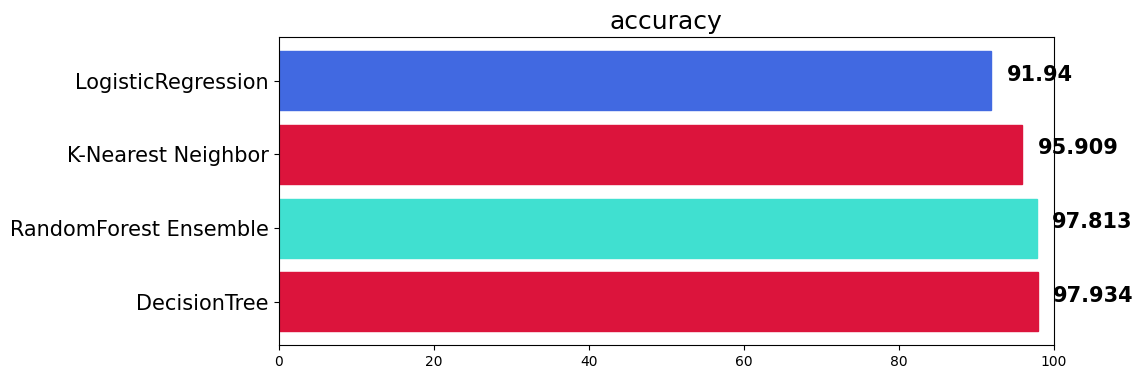

In [138]:
accuracy_eval('RandomForest Ensemble', rfc_pred, y_test)

####  
### **5) XGBoost**
+ 여러개의 DecisionTree를 결합하여 Strong Learner 만드는 Boosting 앙상블 기법
+ Kaggle 대회에서 자주 사용하는 모델이다.

**주요 특징** ⭐️
- scikit-learn 패키지가 아닙니다.
- 성능이 우수함
- GBM보다는 빠르고 성능도 향상되었습니다.
- 여전히 학습시간이 매우 느리다

**주요 Hyperparameter** ⭐️
- random_state: 랜덤 시드 고정 값. 고정해두고 튜닝할 것!
- n_jobs: CPU 사용 갯수
- learning_rate: 학습율. 너무 큰 학습율은 성능을 떨어뜨리고, 너무 작은 학습율은 학습이 느리다. 적절한 값을 찾아야함. n_estimators와 같이 튜닝. default=0.1
- n_estimators: 부스팅 스테이지 수. (랜덤포레스트 트리의 갯수 설정과 비슷한 개념). default=100
- max_depth: 트리의 깊이. 과대적합 방지용. default=3. 
- subsample: 샘플 사용 비율. 과대적합 방지용. default=1.0
- max_features: 최대로 사용할 feature의 비율. 과대적합 방지용. default=1.0

In [139]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 5.1 MB/s  0:00:00 eta 0:00:01


In [ ]:
from xgboost import XGBClassifier, XGBRegressor

In [142]:
xgb = XGBClassifier(n_estimators=3, random_state=42)  
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [143]:
xgb_pred = xgb.predict(X_test)

                   model   accuracy
0           DecisionTree  97.934386
1                XGBoost  97.893884
2  RandomForest Ensemble  97.812880
3     K-Nearest Neighbor  95.909275
4     LogisticRegression  91.940057


<Figure size 1200x900 with 0 Axes>

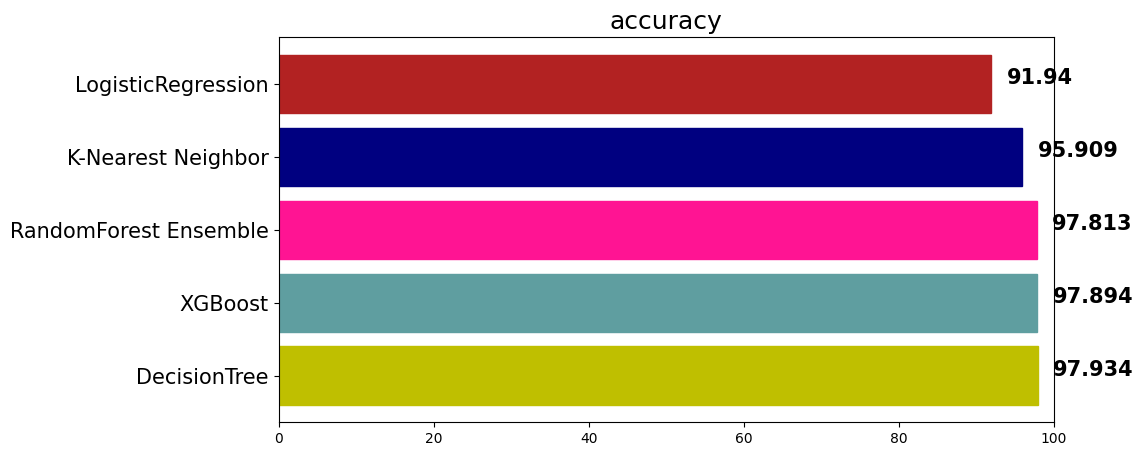

In [144]:
accuracy_eval('XGBoost', xgb_pred, y_test)

# 
# **배운 내용 정리**
1. 머신러닝 모델 프로세스 <br>
① 라이브러리 임포트(import)  
② 데이터 가져오기(Loading the data)  
③ 탐색적 데이터 분석(Exploratory Data Analysis)  
④ 데이터 전처리(Data PreProcessing) : 데이터타입 변환, Null 데이터 처리, 누락데이터 처리, 
더미특성 생성, 특성 추출 (feature engineering) 등  
⑤ Train, Test  데이터셋 분할  
⑥ 데이터 정규화(Normalizing the Data)  
⑦ 모델 개발(Creating the Model)  
⑧ 모델 성능 평가
2. 평가 지표 활용 : 모델별 성능 확인을 위한 함수 (가져다 쓰면 된다)
3. 단일 회귀예측 모델 : LogisticRegression, KNN, DecisionTree
4. 앙상블 (Ensemble) : RandomForest, XGBoost